# 1. Obiettivo 

In questo progetto affrontiamo un problema di classificazione di immagini usando il dataset CIFAR-10.  

Lo scopo del progetto è classificare ogni immagine del dataset CIFAR-10 in una delle 10 classi disponibili.  

Le classi rappresentano sia mezzi di trasporto sia animali, quindi il modello dovrà imparare a riconoscere forme, colori e caratteristiche visive diverse.

Oltre a costruire una CNN funzionante, vogliamo anche ottimizzarne le prestazioni.  
Per farlo utilizzeremo tecniche come normalizzazione dei pixel, dropout, batch normalization e data augmentation, con l’obiettivo di migliorare la capacità del modello di generalizzare su immagini mai viste prima.


# 2. Strategia

La strategia del progetto segue una sequenza logica.

Per prima cosa analizzeremo il dataset per capire che tipo di immagini contiene e quali difficoltà presenta.  
Successivamente prepareremo i dati per il training, normalizzando i pixel e organizzando correttamente training, validation e test set.

A quel punto costruiremo una baseline, cioè un primo modello semplice ma corretto, che useremo come punto di partenza.  
Dopo aver osservato il suo comportamento, introdurremo progressivamente miglioramenti per ridurre l’overfitting e aumentare l’accuracy.

Infine confronteremo i vari modelli, sceglieremo quello migliore e ne analizzeremo i risultati tramite grafici, matrice di confusione ed esempi concreti di predizioni corrette e sbagliate.


# 3. Import librerie

In [1]:
import os
from pathlib import Path
import random
import pandas as pd


#os.environ["KERAS_BACKEND"] = "torch"
# per usare pythorc "sotto" keras

import numpy as np
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout
from keras.utils import to_categorical
import matplotlib.pyplot as plt
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam

# 4. Caricamento dataset

Dataset: CIFAR-10

Immagini a colori 32x32 suddivise in 10 classi.

TODO:
- ✅ stampa delle dimensioni di:
  - x_train
  - y_train
  - x_test
  - y_test



In [2]:
# from sklearn.model_selection import train_test_split
from keras.utils import to_categorical
from tensorflow.keras.datasets import cifar10

# Caricamento dataset CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("x_train shape:", x_train.shape)
# print("x_val shape  :", x_val.shape)
print("x_test shape :", x_test.shape)

print("y_train shape:", y_train.shape)
# print("y_val shape  :", y_val.shape)
print("y_test shape :", y_test.shape)

C:\Users\Mary_Rosy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


x_train shape: (50000, 32, 32, 3)
x_test shape : (10000, 32, 32, 3)
y_train shape: (50000, 1)
y_test shape : (10000, 1)


# 5. Visualizzazione di prova delle immagini

Prima di allenare il modello è utile osservare visivamente alcune immagini per capire la varietà del dataset e la difficoltà del compito.

TODO
- ✅ Visualizzazione di alcune immagini del training set con etichetta corrispondente.
- ✅ Mostrare almeno un esempio per classe.

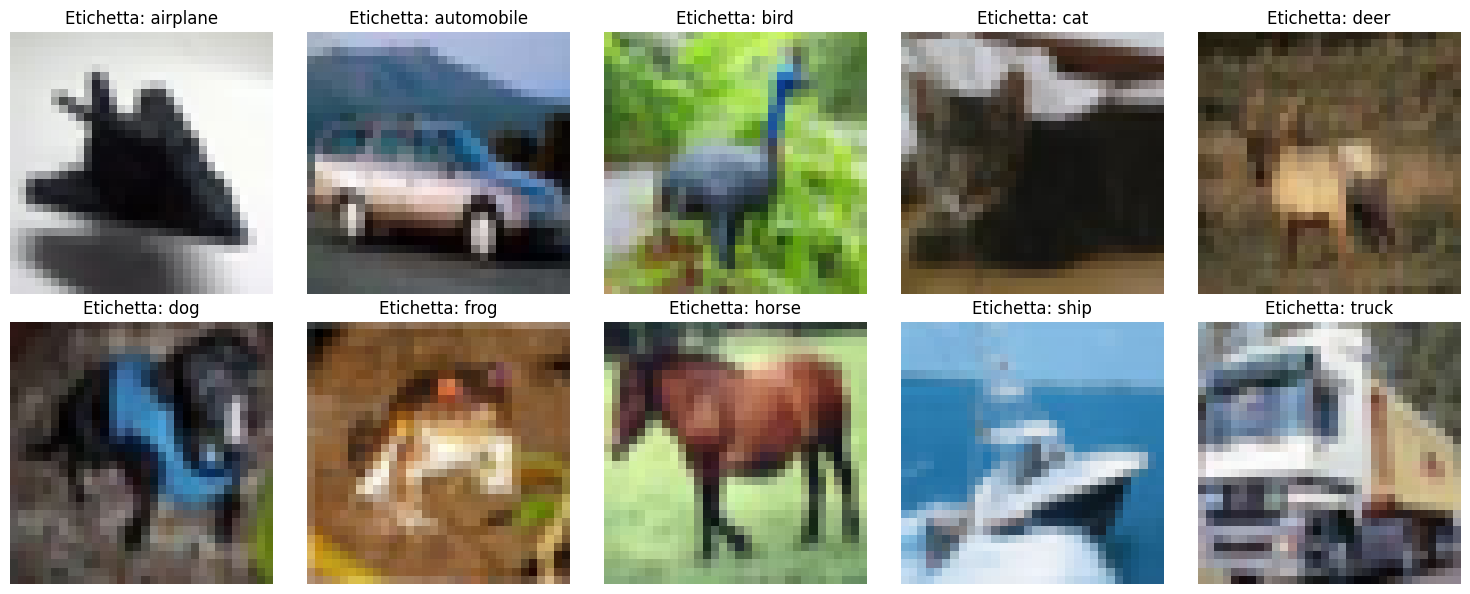

In [3]:
plt.figure(figsize=(15, 6))

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

for class_index, class_name in enumerate(class_names):
    img_index = np.where(y_train.squeeze() == class_index)[0][0]

    plt.subplot(2, 5, class_index + 1)
    plt.imshow(x_train[img_index])
    plt.title(f'Etichetta: {class_name}')
    plt.axis('off')

plt.tight_layout()
plt.show()

# 6. Analisi delle classi

Verificare se il dataset è bilanciato e quante immagini ci sono per ciascuna classe.

TODO
- Conteggio delle immagini per classe e grafico semplice della distribuzione.

       Classe  Numero immagini
0    airplane             5000
1  automobile             5000
2        bird             5000
3         cat             5000
4        deer             5000
5         dog             5000
6        frog             5000
7       horse             5000
8        ship             5000
9       truck             5000


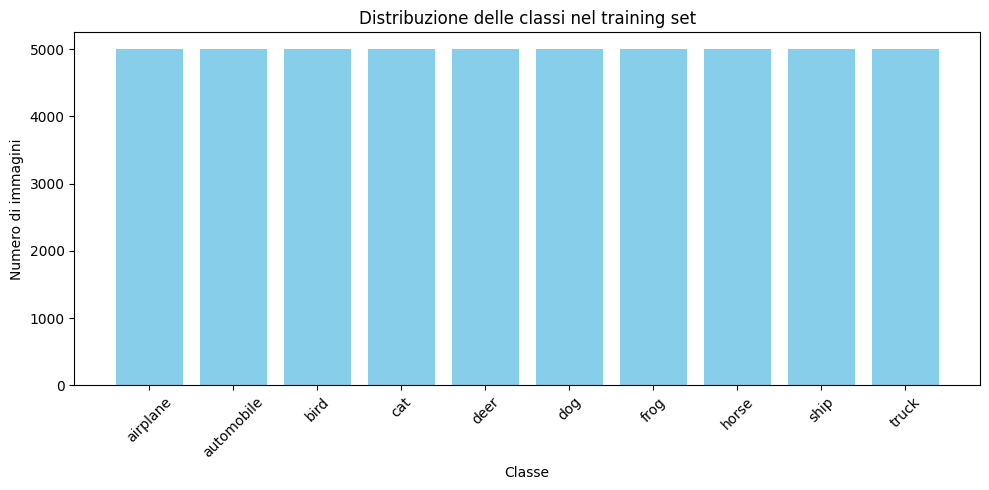

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Controlliamo la forma di y_train per decidere come contare
if len(y_train.shape) > 1 and y_train.shape[1] > 1:
    # Caso One-Hot Encoding (se hai usato to_categorical)
    class_counts = np.sum(y_train, axis=0)
else:
    # Caso Numeri Interi (default di cifar10.load_data)
    # Usiamo np.unique per contare le occorrenze di ogni etichetta
    classes, counts = np.unique(y_train, return_counts=True)
    class_counts = counts

# Ora class_counts e class_names hanno entrambi lunghezza 10
df_classes = pd.DataFrame({
    'Classe': class_names,
    'Numero immagini': class_counts.astype(int)
})

print(df_classes)

# Visualizzazione grafica
plt.figure(figsize=(10, 5))
plt.bar(df_classes['Classe'], df_classes['Numero immagini'], color='skyblue')
plt.title('Distribuzione delle classi nel training set')
plt.xlabel('Classe')
plt.ylabel('Numero di immagini')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 7. Preprocessing

Normalizzazione dei pixel per rendere il training più stabile e preparazione dei dati nel formato corretto per il modello.

TODO
- ✅ conversione dei pixel in float
- ✅ divisione per 255: le immagini originali hanno pixel compresi tra `0` e `255`. dividendo per `255`, i valori vengono portati nell'intervallo `0-1`. questo rende il training più stabile, perché la rete lavora meglio con dati su scale più piccole e omogenee.
- ✅ one-hot encoding delle etichette
  - Esempio: 3` diventa `[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]`. Questo formato è coerente con l'uso della loss: **`categorical_crossentropy`** che misura quanto la distribuzione di probabilità predetta dal modello è lontana dalla classe corretta.


In [7]:
# from sklearn.model_selection import train_test_split
from keras.utils import to_categorical


# One-hot encoding delle etichette
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)


# Normalizzazione 
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# 5. Controllo finale delle shape
print("x_train shape:", x_train.shape)
# print("x_val shape  :", x_val.shape)
print("x_test shape :", x_test.shape)

print("y_train shape:", y_train.shape)
# print("y_val shape  :", y_val.shape)
print("y_test shape :", y_test.shape)

x_train shape: (50000, 32, 32, 3)
x_test shape : (10000, 32, 32, 3)
y_train shape: (50000, 10)
y_test shape : (10000, 10)


# 8. Baseline CNN

Primo modello di riferimento

TODO
- ✅ Definizione della CNN base.
- ✅ `model.summary()` per
  - mostra la struttura della rete
  - fa vedere numero di parametri
  - aiuta a documentare il modello


### Spiegazione
- Conv2D(32, (3,3)): applica 32 filtri 3x3 per cercare pattern locali, come bordi e forme semplici.
- MaxPooling2D((2,2)): riduce la dimensione delle mappe di attivazione, mantenendo le informazioni più rilevanti.
- secondo blocco convoluzionale: aumenta i filtri a 64, così il modello può riconoscere pattern più complessi.
- Flatten(): trasforma il tensore 3D in un vettore 1D.
- Dense(64): combina le caratteristiche estratte.
- Dense(10, softmax): produce una probabilità per ciascuna delle 10 classi.


In [8]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Definizione della CNN base
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# Riassunto del modello
model.summary()

C:\Users\Mary_Rosy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

# 9. Compilazione

Compilazione primo modello di riferimento, semplice ma corretto, usato come punto di partenza per valutare i miglioramenti successivi.

TODO
- ✅ compilazione del modello
  - ✅ scelta dell’optimizer, ad esempio Adam
  - ✅ scelta della loss coerente con il formato delle label
  - ✅ uso di accuracy come metrica principale


### Spiegazione

- **Adam** è un optimizer molto usato perché in genere converge bene e richiede poca taratura iniziale.
- **categorical_crossentropy** è la loss corretta quando:
  - il problema è di classificazione multiclasse
  - il layer finale usa `softmax`
  - le etichette sono codificate in **one-hot encoding**
- **accuracy** indica la percentuale di immagini classificate correttamente.

Questa configurazione è una baseline semplice ma corretta, utile come punto di partenza prima di introdurre tecniche di miglioramento.

In [9]:
from keras.metrics import CategoricalAccuracy

opt = Adam(learning_rate=0.001)

# Compilazione del modello
model.compile(
    optimizer=opt,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 10. Training baseline

Monitoraggio accuracy e loss su training e validation per capire il comportamento del modello.

TODO
- ✅ Training del modello base con salvataggio della history
- ✅ non deve mancare la validation_split nella history, per la creazione del validation set a partire dal training set
- ✅ EarlyStopping, per fermare il training quando la validation loss smette di migliorare
- ✅ ReduceLROnPlateau, riduzione automatica del learning rate se il modello si blocca

## Spiegazione

### Early Stopping

L’**Early Stopping** interrompe il training quando la loss di validazione smette di migliorare per un certo numero di epoche consecutive.

Questo è utile perché:
- evita di allenare inutilmente il modello;
- riduce il rischio di overfitting;
- ripristina automaticamente i pesi migliori trovati durante il training.

### ReduceLROnPlateau

La callback **ReduceLROnPlateau** riduce automaticamente il learning rate (tasso d'apprendimento/passo - indica quanto velocemente il modello aggiona i pesi durante l'addestramento) quando la validazione smette di migliorare.

Questo è utile perché:
- all’inizio il modello può imparare più velocemente con un learning rate più alto;
- quando il miglioramento rallenta, un learning rate più basso permette una rifinitura più precisa.

### Validation split

La validazione viene ricavata automaticamente dal training set tramite `validation_split=0.1`.

Questo significa che:
- il 90% di `x_train` e `y_train` viene usato per allenare il modello;
- il 10% viene usato internamente come validation set.

È una soluzione pratica e molto comune quando non si vuole gestire manualmente una suddivisione separata.


In [10]:
# assicuriamoci che le label siano sparse 1D
y_train = y_train.squeeze()
y_test = y_test.squeeze()

print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)
print("Prime 10 label:", y_train[:10])

# compilazione
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 6. Callbacks
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=7, 
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# training
history = model.fit(
    x_train,
    y_train,
    epochs=200,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr]
)

y_train shape: (50000, 10)
y_test shape : (10000, 10)
Prime 10 label: [[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]
Epoch 1/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.4278 - loss: 1.5764 - val_accuracy: 0.5198 - val_loss: 1.3819 - learning_rate: 0.0010
Epoch 2/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step - accuracy: 0.5702 - loss: 1.2190 - val_accuracy: 0.6024 - val_loss: 1.1393 - learning_rate: 0.0010
Epoch 3/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 36ms/step - accuracy: 0.6230 - loss: 1.0761 - val_accuracy: 0.6306 - val_loss: 1.0649 - learning_rate: 0.0010
Epoch 4/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.6573 - loss: 0.9824 - val_accuracy: 0.6582 - val_loss: 0.9860 - l

# 11. Grafici baseline

Osservazione di come il modello ha imparato nel tempo e individuazione eventuale overfitting.

TODO
- ✅ Grafico accuracy training/validation
- ✅ Grafico loss training/validation

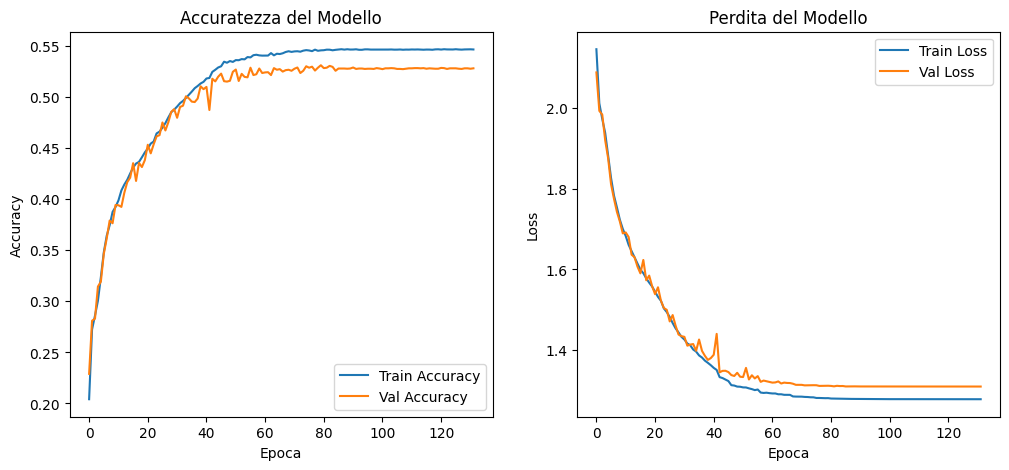

In [ ]:
# Creiamo una figura con due grafici (Sottoplot)
plt.figure(figsize=(12, 5))

# Grafico della Precisione (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuratezza del Modello')
plt.xlabel('Epoca')
plt.ylabel('Accuracy')
plt.legend()

# Grafico della Perdita (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Perdita del Modello')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.legend()

plt.show()

# 12. Prima valutazione 

Risultato iniziale ottenuto e commento breve se il modello sembra promettente oppure se mostra già limiti evidenti.

TODO
- ✅ Valutazione del modello su validation (quella salvata da validation_split nel punto 10)

In [ ]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f'Perdita sul test set: {test_loss:.4f}')
print(f'Accuratezza sul test set: {test_accuracy:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5295 - loss: 1.3266
Perdita sul test set: 1.3266
Accuratezza sul test set: 0.5295


# 13. Miglioramenti: batch normalization, dropout, data augmentation

Rispetto alla baseline, questo modello è più profondo e introduce tecniche specifiche per migliorare la generalizzazione.

Questo modello è più complesso della baseline, quindi richiede più tempo di addestramento. Tuttavia, la maggiore complessità è giustificata dal tentativo di ottenere prestazioni migliori su validation e test set, non solo sul training set.

## 13.1 ✅ Batch Normalization - rende il training più stabile

### Spiegazione

La **Batch Normalization** aiuta a stabilizzare i valori che passano tra i layer della rete durante l’addestramento. Questo rende il training più regolare e spesso più veloce.

In pratica:
- rende l’ottimizzazione più stabile;
- aiuta la rete a convergere meglio;
- spesso migliora le prestazioni finali.

## 13.2 ✅ Dropout - aiuta a ridurre l’overfitting

### Spiegazione

Il **Dropout** spegne casualmente una parte dei neuroni durante il training. In questo modo il modello non si affida sempre agli stessi percorsi interni e impara rappresentazioni più robuste.

Serve soprattutto per:
- ridurre l’overfitting;
- rendere il modello meno “dipendente” da singoli neuroni;
- migliorare la generalizzazione.

## 13.3 ✅ Data Augmentation - aumenta la varietà delle immagini viste durante il training

### Spiegazione

La **Data Augmentation** consiste nel generare versioni leggermente modificate delle immagini di training, per esempio con:
- ribaltamento orizzontale;
- piccole rotazioni;
- piccole traslazioni.

Questo permette di mostrare al modello immagini più varie, aiutandolo a imparare caratteristiche più generali invece di memorizzare solo le immagini originali.

È importante ricordare che:
- la data augmentation si applica **solo al training set**;
- validation e test set devono restare invariati, così la valutazione rimane corretta.

In [ ]:
# 13. Modello migliorato con Batch Normalization, Dropout e Data Augmentation

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Flatten, Dense,
    Dropout, BatchNormalization
)
from tensorflow.keras.regularizers import l2

tf.random.set_seed(42)

# Data augmentation: trasformazioni leggere e realistiche per CIFAR-10

data_augmentation = Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomTranslation(0.1, 0.1)
], name="data_augmentation")

# CNN migliorata
improved_model = Sequential([
    Input(shape=(32, 32, 3)),

    # augmentation attiva solo durante il training
    data_augmentation,

    # Blocco 1
    Conv2D(32, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(32, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Blocco 2
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.30),

    # Blocco 3
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.40),

    # Classificatore finale
    Flatten(),
    Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.50),
    Dense(10, activation='softmax')
])

# Compilazione coerente con etichette one-hot
improved_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

improved_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,29

 Total params: 404,778 (1.54 MB)

 Trainable params: 403,882 (1.54 MB)

 Non-trainable params: 896 (3.50 KB)

# 14. Training modello migliorato

Rieseguire l'allenamento con una versione più robusta del modello, combinando le tecniche introdotte.

TODO
- ✅ Training del modello migliorato con salvataggio history.
- ✅ OPZIONALE: fissare seed random per riproducibilità (fatto nel punto 13)

# 14. Addestramento del modello migliorato

Dopo aver definito l’architettura migliorata, passiamo alla fase di addestramento ✅.

Per allenare il modello in modo più efficiente utilizziamo due callback già definite, ricopiate solo per l'eventualità di poter modificare per questo modello alcuni dei paramentri.



In [ ]:
# 14. Training del modello migliorato

early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=7, 
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history_improved = improved_model.fit(
    x_train,
    y_train,
    epochs=200,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 126s 178ms/step - accuracy: 0.3666 - loss: 1.8458 - val_accuracy: 0.1768 - val_loss: 3.1907 - learning_rate: 0.0010
Epoch 2/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 131s 187ms/step - accuracy: 0.4883 - loss: 1.4550 - val_accuracy: 0.4176 - val_loss: 1.7927 - learning_rate: 0.0010
Epoch 3/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 132s 187ms/step - accuracy: 0.5417 - loss: 1.3203 - val_accuracy: 0.4938 - val_loss: 1.3744 - learning_rate: 0.0010
Epoch 4/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 130s 185ms/step - accuracy: 0.5814 - loss: 1.2169 - val_accuracy: 0.3282 - val_loss: 2.0601 - learning_rate: 0.0010
Epoch 5/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 126s 179ms/step - accuracy: 0.6088 - loss: 1.1567 - val_accuracy: 0.0992 - val_loss: 3.9443 - learning_rate: 0.0010
Epoch 6/200
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.6092 - loss: 1.1564
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
704/704 ━━━━━━━━━━━━━━━━━━━━ 126s 180ms/step - acc

# 15. Grafici modello migliorato - ⚡⚡⚡ENTRO MERCOLEDI POMERIGGIO

Il nuovo modello ha migliorato la validation accuracy e se ha ridotto l’overfitting rispetto alla baseline?

TODO
- ✅ Grafici di accuracy e loss del modello migliorato.

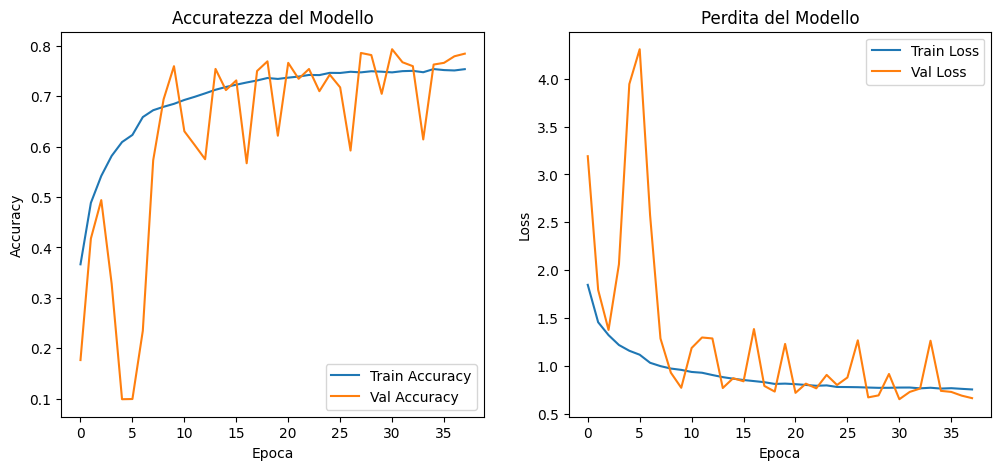

In [ ]:
# Creiamo una figura con due grafici (Sottoplot)
plt.figure(figsize=(12, 5))

# Grafico della Precisione (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(history_improved.history['accuracy'], label='Train Accuracy')
plt.plot(history_improved.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuratezza del Modello')
plt.xlabel('Epoca')
plt.ylabel('Accuracy')
plt.legend()

# Grafico della Perdita (Loss)
plt.subplot(1, 2, 2)
plt.plot(history_improved.history['loss'], label='Train Loss')
plt.plot(history_improved.history['val_loss'], label='Val Loss')
plt.title('Perdita del Modello')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
test_loss, test_accuracy = improved_model.evaluate(x_test, y_test)
print(f'Perdita sul test set: {test_loss:.4f}')
print(f'Accuratezza sul test set: {test_accuracy:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7820 - loss: 0.6819
Perdita sul test set: 0.6819
Accuratezza sul test set: 0.7820


## Analisi dei miglioramenti

L’addestramento del modello migliorato mostra un andamento complessivamente positivo: la training accuracy cresce e la training loss diminuisce in modo regolare. 

Le curve di validazione risultano invece più instabili, con oscillazioni anche marcate tra un’epoca e l’altra. Questo comportamento è plausibile perché durante il training sono attive tecniche di regolarizzazione come Data Augmentation e Dropout, che rendono il compito più difficile rispetto alla validazione. 

Nonostante queste oscillazioni, il modello ottiene un netto miglioramento rispetto alla baseline, raggiungendo un’accuratezza sul test set pari a 0.7820.

# 16. Confronto tra modelli

Punto impostante: cosa è cambiato e perché il modello finale è migliore, oppure in quali aspetti lo è?

Dopo aver addestrato e valutato entrambi i modelli, è utile confrontarli in modo diretto per capire se le modifiche introdotte hanno prodotto un miglioramento reale.

In questa sezione analizziamo:
- ✅ l’andamento dell’accuratezza durante il training;
- ✅ l’andamento della loss durante il training;
- ✅ una tabella riassuntiva con i principali risultati finali.

Questo confronto è importante perché permette di verificare non solo il risultato finale sul test set, ma anche il comportamento dei due modelli durante l’addestramento. In particolare, ci interessa osservare se il modello migliorato:
- raggiunge una validation accuracy più alta;
- ottiene una test accuracy migliore;
- mantiene una loss più bassa;
- mostra una migliore capacità di generalizzazione rispetto alla baseline.

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5295 - loss: 1.3266
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7820 - loss: 0.6819


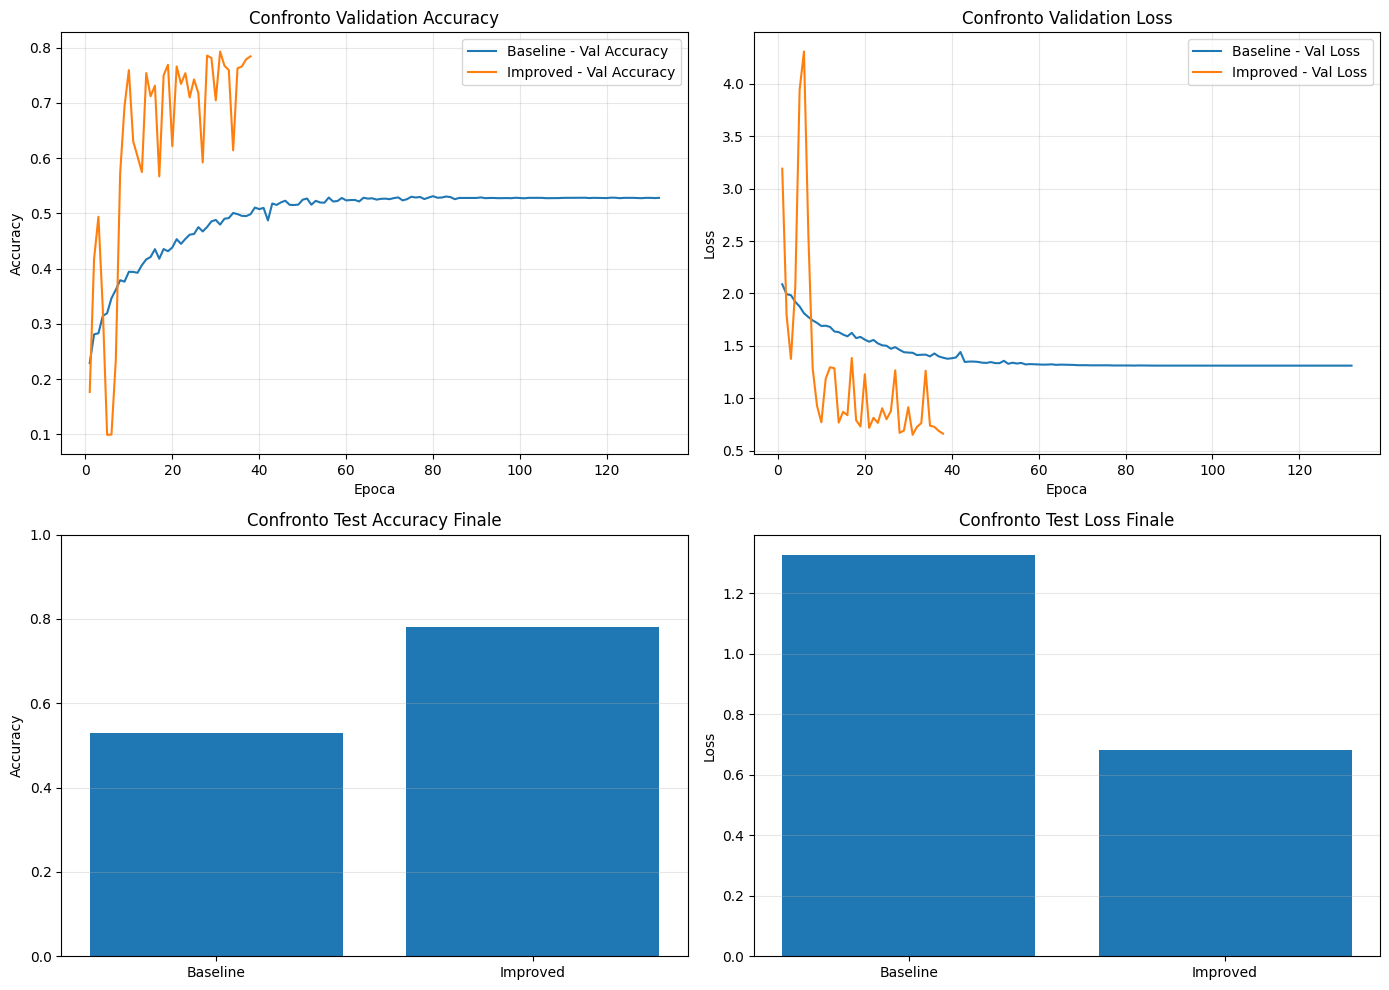

,Modello,Epoche eseguite,Miglior Val Accuracy,Miglior Val Loss,Test Accuracy,Test Loss
0,Baseline,132,0.5310,1.3105,0.5295,1.3266
1,Improved,38,0.7928,0.6500,0.7820,0.6819


In [ ]:
# 16. Confronto tra baseline e modello migliorato con grafici affiancati

import pandas as pd
import matplotlib.pyplot as plt

# === Valutazione dei modelli sul test set ===
baseline_test_loss, baseline_test_accuracy = model.evaluate(x_test, y_test, verbose=1)
improved_test_loss, improved_test_accuracy = improved_model.evaluate(x_test, y_test, verbose=1)

# === Estrazione metriche dalla history ===
baseline_train_acc = history.history['accuracy']
baseline_val_acc = history.history['val_accuracy']
baseline_train_loss = history.history['loss']
baseline_val_loss = history.history['val_loss']

improved_train_acc = history_improved.history['accuracy']
improved_val_acc = history_improved.history['val_accuracy']
improved_train_loss = history_improved.history['loss']
improved_val_loss = history_improved.history['val_loss']

# === Numero epoche ===
epochs_baseline = range(1, len(baseline_train_acc) + 1)
epochs_improved = range(1, len(improved_train_acc) + 1)

# =========================
# Grafici affiancati 2x2
# =========================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Validation Accuracy
axes[0, 0].plot(epochs_baseline, baseline_val_acc, label='Baseline - Val Accuracy')
axes[0, 0].plot(epochs_improved, improved_val_acc, label='Improved - Val Accuracy')
axes[0, 0].set_title('Confronto Validation Accuracy')
axes[0, 0].set_xlabel('Epoca')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Validation Loss
axes[0, 1].plot(epochs_baseline, baseline_val_loss, label='Baseline - Val Loss')
axes[0, 1].plot(epochs_improved, improved_val_loss, label='Improved - Val Loss')
axes[0, 1].set_title('Confronto Validation Loss')
axes[0, 1].set_xlabel('Epoca')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Test Accuracy finale
model_names = ['Baseline', 'Improved']
test_accuracies = [baseline_test_accuracy, improved_test_accuracy]

axes[1, 0].bar(model_names, test_accuracies)
axes[1, 0].set_title('Confronto Test Accuracy Finale')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Test Loss finale
test_losses = [baseline_test_loss, improved_test_loss]

axes[1, 1].bar(model_names, test_losses)
axes[1, 1].set_title('Confronto Test Loss Finale')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# =========================
# Tabella comparativa
# =========================
comparison_df = pd.DataFrame({
    'Modello': ['Baseline', 'Improved'],
    'Epoche eseguite': [len(baseline_train_acc), len(improved_train_acc)],
    'Miglior Val Accuracy': [max(baseline_val_acc), max(improved_val_acc)],
    'Miglior Val Loss': [min(baseline_val_loss), min(improved_val_loss)],
    'Test Accuracy': [baseline_test_accuracy, improved_test_accuracy],
    'Test Loss': [baseline_test_loss, improved_test_loss]
})

comparison_df['Miglior Val Accuracy'] = comparison_df['Miglior Val Accuracy'].round(4)
comparison_df['Miglior Val Loss'] = comparison_df['Miglior Val Loss'].round(4)
comparison_df['Test Accuracy'] = comparison_df['Test Accuracy'].round(4)
comparison_df['Test Loss'] = comparison_df['Test Loss'].round(4)

display(comparison_df)

# 17. Matrice di confusione

Permette di capire quali classi vengono riconosciute bene e quali vengono confuse più spesso.

TODO
- ✅ Costruzione e visualizzazione della confusion matrix

### Spiegazione

Dopo aver valutato il modello con accuracy e loss, analizziamo il comportamento in modo più dettagliato tramite la **matrice di confusione**.

La matrice di confusione permette di vedere:
- quante immagini di ogni classe vengono classificate correttamente;
- quali classi vengono confuse più spesso tra loro;
- dove il modello è più forte e dove è più debole.

Nel caso di CIFAR-10, questa analisi è particolarmente utile perché alcune classi sono visivamente simili, ad esempio:
- automobile e truck;
- cat e dog;
- deer e horse;
- ship e airplane in certe immagini poco nitide.

La diagonale principale della matrice rappresenta le classificazioni corrette.  
I valori fuori diagonale rappresentano invece gli errori, cioè le confusioni tra classi diverse.

L’obiettivo è capire non solo **quanto** il modello funziona bene, ma anche **come** sbaglia.

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


<Figure size 1000x800 with 0 Axes>

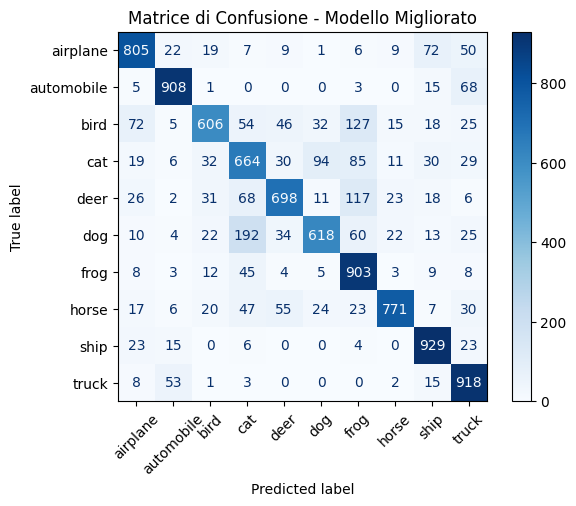

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Nomi delle classi CIFAR-10
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Predizioni del modello sul test set
y_pred_probs = improved_model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Etichette reali: da one-hot a indici di classe
y_true = np.argmax(y_test, axis=1)

# Matrice di confusione
cm = confusion_matrix(y_true, y_pred)

# Visualizzazione
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45, values_format="d")
plt.title("Matrice di Confusione - Modello Migliorato")
plt.show()

## Analisi della matrice di confusione

La matrice di confusione mostra che il modello migliorato ottiene risultati molto buoni su diverse classi del dataset CIFAR-10. In particolare, le classi **ship**, **truck**, **automobile** e **frog** presentano valori molto alti sulla diagonale principale, segno che vengono riconosciute correttamente nella maggior parte dei casi.

Le classi più difficili risultano invece essere **bird**, **cat**, **dog** e **deer**. Questo comportamento è plausibile perché si tratta di categorie visivamente simili, soprattutto considerando che le immagini di CIFAR-10 hanno una risoluzione molto bassa (32x32 pixel). In queste condizioni, molti dettagli utili per distinguere gli animali si perdono.

L’errore più evidente è la confusione tra **dog** e **cat**, che rappresenta una delle criticità principali del modello. Sono presenti anche confusioni tra **automobile** e **truck**, e tra alcune classi animali come **deer**, **bird** e **frog**.

Nel complesso, la matrice conferma che il modello ha appreso bene le classi con caratteristiche visive più distintive, mentre fatica di più nelle classi che richiedono feature più fini e dettagliate. Questo suggerisce che ulteriori miglioramenti potrebbero arrivare da un’architettura leggermente più profonda e da tecniche che favoriscano una migliore estrazione delle caratteristiche complesse.

# 18. Esempi di errori e successi

Spiegazione e osservazione di esempi **concreti** aiuta a capire i punti di forza e i limiti del modello.

TODO
- ✅ Mostrare
    - alcuni esempi di **predizioni corrette**;
    - alcuni esempi di **predizioni errate**;
    - alcune confusioni interessanti emerse dalla matrice di confusione, come ad esempio immagini di una classe reale che vengono scambiate per un’altra.

Numero di esempi corretti: 7820
Numero di esempi errati: 2180


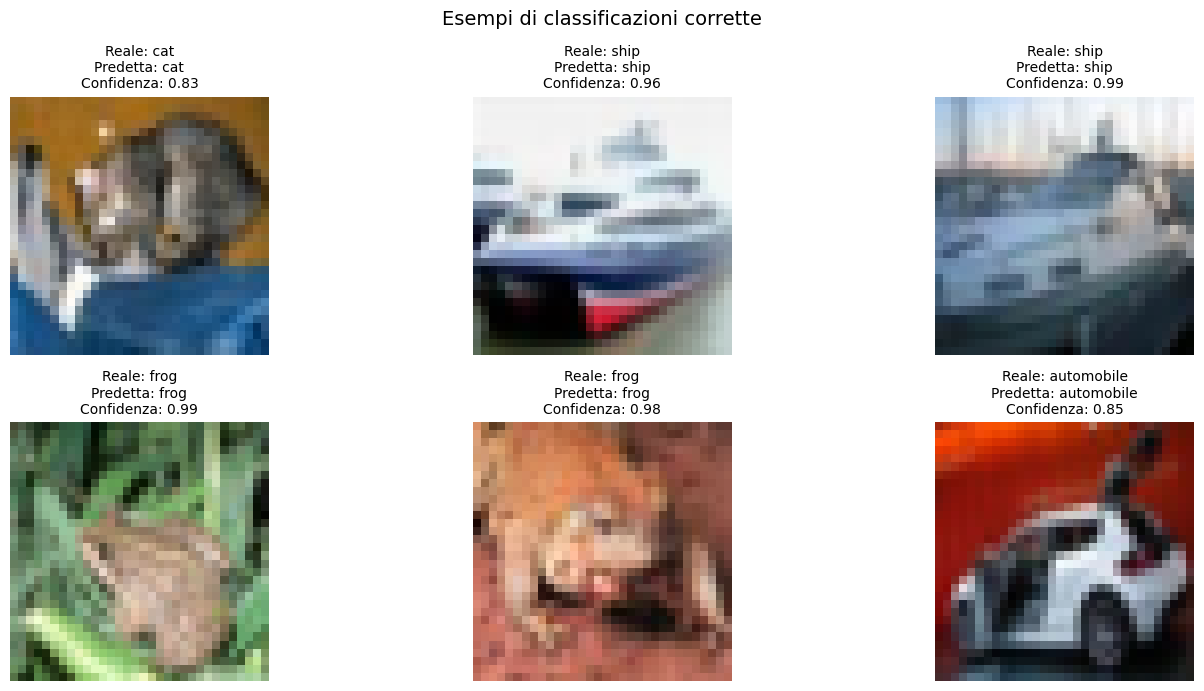

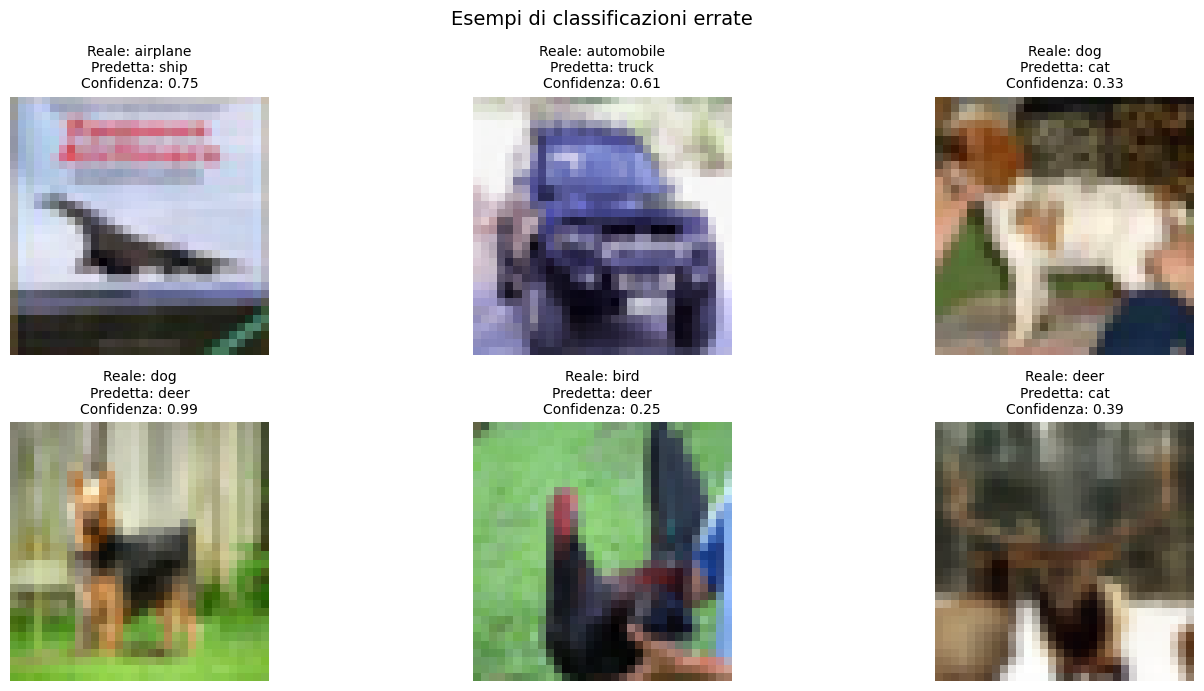

Esempi di confusione dog -> cat: 192


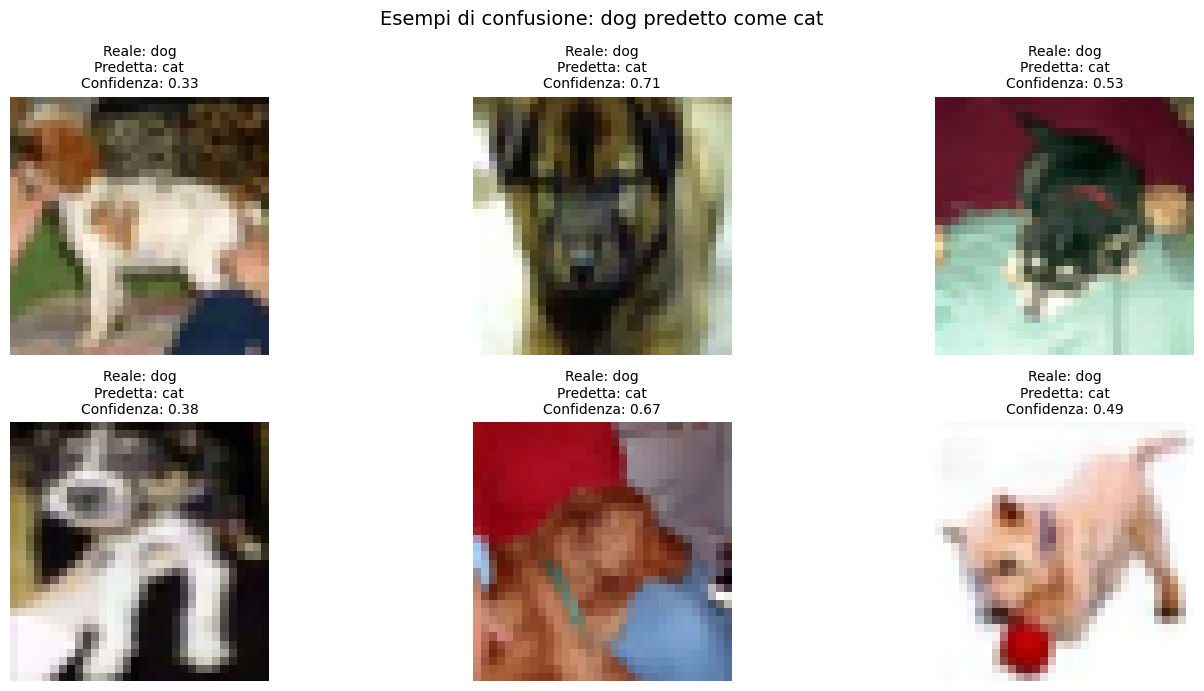

In [ ]:
# Nomi classi CIFAR-10
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Predizioni sul test set
y_pred_probs = improved_model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Indici immagini corrette e sbagliate
correct_indices = np.where(y_pred == y_true)[0]
wrong_indices = np.where(y_pred != y_true)[0]

print(f"Numero di esempi corretti: {len(correct_indices)}")
print(f"Numero di esempi errati: {len(wrong_indices)}")


def prepare_image_for_display(img):
    """
    Adatta l'immagine solo per la visualizzazione.
    Funziona sia se i pixel sono in [0,1], sia se sono standardizzati
    o fuori range.
    """
    img = img.copy()

    # Se ci sono valori fuori da [0,1], li riportiamo in [0,1]
    img_min = img.min()
    img_max = img.max()

    if img_max > img_min:
        img = (img - img_min) / (img_max - img_min)
    else:
        img = np.zeros_like(img)

    return img


def show_examples(indices, title, n=6):
    plt.figure(figsize=(15, 7))
    selected = indices[:n]

    for i, idx in enumerate(selected):
        plt.subplot(2, 3, i + 1)

        img_to_show = prepare_image_for_display(x_test[idx])
        plt.imshow(img_to_show)

        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred[idx]]
        confidence = y_pred_probs[idx][y_pred[idx]]

        plt.title(
            f"Reale: {true_label}\nPredetta: {pred_label}\nConfidenza: {confidence:.2f}",
            fontsize=10
        )
        plt.axis("off")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


# =========================
# 1. Esempi corretti
# =========================
show_examples(correct_indices, "Esempi di classificazioni corrette", n=6)

# =========================
# 2. Esempi errati
# =========================
show_examples(wrong_indices, "Esempi di classificazioni errate", n=6)

# =========================
# 3. Esempi di una confusione specifica emersa dalla matrice
#    esempio: immagini reali di dog predette come cat
# =========================
true_class_name = "dog"
pred_class_name = "cat"

true_class = class_names.index(true_class_name)
pred_class = class_names.index(pred_class_name)

specific_confusion_indices = np.where((y_true == true_class) & (y_pred == pred_class))[0]

print(f"Esempi di confusione {true_class_name} -> {pred_class_name}: {len(specific_confusion_indices)}")

if len(specific_confusion_indices) > 0:
    show_examples(
        specific_confusion_indices,
        f"Esempi di confusione: {true_class_name} predetto come {pred_class_name}",
        n=min(6, len(specific_confusion_indices))
    )
else:
    print("Nessun esempio trovato per questa confusione specifica.")

# 19. Conclusioni

In questo progetto è stato sviluppato un sistema di **classificazione di immagini** sul dataset **CIFAR-10**, con l’obiettivo di riconoscere automaticamente 10 categorie diverse di oggetti e animali a partire da immagini a bassa risoluzione.

Il lavoro è partito da una fase iniziale di **preprocessing**, in cui i dati sono stati caricati, analizzati e normalizzati per renderli adatti all’addestramento della rete neurale. Successivamente è stata costruita una prima **CNN baseline**, utile come punto di partenza per valutare il comportamento del modello su questo tipo di problema.

Dopo aver osservato i risultati iniziali, il modello è stato migliorato introducendo tecniche più avanzate, tra cui **Batch Normalization**, **Dropout** e **Data Augmentation**. Queste modifiche hanno permesso di rendere l’addestramento più stabile e di migliorare la capacità di generalizzazione del modello. Per controllare meglio il training sono stati utilizzati anche strumenti come **Early Stopping** e **ReduceLROnPlateau**, che hanno aiutato a fermare l’addestramento nel momento opportuno e a regolare il learning rate durante le epoche.

Il confronto tra i modelli ha mostrato chiaramente che il modello migliorato ha funzionato meglio della baseline. La baseline otteneva infatti prestazioni più limitate, mentre il modello migliorato ha raggiunto risultati significativamente superiori sia in termini di **accuracy** sia in termini di **loss** sul test set. Questo dimostra che le tecniche introdotte non hanno solo aumentato la complessità della rete, ma hanno prodotto un miglioramento reale nella capacità di classificare immagini mai viste.

Tra le tecniche utilizzate, quelle che hanno contribuito maggiormente al miglioramento sono state soprattutto:
- la **Data Augmentation**, che ha reso il modello più robusto mostrando immagini leggermente variate durante il training;
- il **Dropout**, che ha ridotto il rischio di overfitting;
- la **Batch Normalization**, che ha reso l’addestramento più stabile e regolare.

L’analisi della **matrice di confusione** ha mostrato che alcune classi sono risultate più facili da riconoscere, mentre altre si sono rivelate più difficili. In particolare, classi come **ship**, **truck**, **automobile** e **frog** sono state riconosciute molto bene, mentre classi come **cat**, **dog**, **bird** e **deer** hanno generato più errori. Questo è dovuto soprattutto alla bassa risoluzione delle immagini e alla somiglianza visiva tra alcune categorie, che rende più difficile distinguere dettagli fini.

L’osservazione di esempi concreti di immagini classificate correttamente e in modo errato ha confermato quanto emerso dai grafici e dalla matrice di confusione: il modello funziona bene nei casi in cui l’oggetto è visivamente chiaro e ben distinguibile, mentre incontra difficoltà quando l’immagine è più ambigua, poco nitida o contiene classi molto simili tra loro.

In futuro il progetto potrebbe essere migliorato ulteriormente in diversi modi. Per esempio, si potrebbe sperimentare una rete ancora più raffinata, con architetture più profonde o con un pooling finale diverso. Si potrebbero introdurre nuove tecniche di **augmentation**, come variazioni leggere di luminosità e contrasto, oppure strategie più avanzate come **Mixup**. Un’altra possibilità sarebbe quella di eseguire una fase di tuning più sistematica degli iperparametri, ad esempio variando learning rate, batch size e struttura dei layer. Infine, si potrebbero confrontare i risultati ottenuti con architetture più moderne per verificare se sia possibile aumentare ancora l’accuratezza.

Nel complesso, il progetto ha mostrato in modo concreto come una CNN possa essere progettata, addestrata, valutata e progressivamente migliorata. Il risultato finale non è solo un modello più accurato, ma anche una pipeline completa di lavoro che comprende preprocessing, progettazione dell’architettura, training, valutazione quantitativa e analisi qualitativa degli errori.

# 20. Export per front-end

Dopo aver addestrato e valutato il modello, è utile esportarlo in un formato che possa essere integrato in un'applicazione front-end.

Nel nostro caso, il modello è stato sviluppato con **Keras**, quindi il primo passo consiste nel salvarlo nel formato nativo `.keras`. Successivamente, se l'obiettivo è usarlo direttamente in un'applicazione web, il modello può essere convertito in formato **TensorFlow.js**, che permette di eseguire inferenza direttamente nel browser con JavaScript.

Oltre al modello, è importante esportare anche alcune informazioni di supporto, come:
- i nomi delle classi;
- la dimensione dell'immagine attesa in input;
- la normalizzazione da applicare;
- il significato dell'output.

Questa parte è fondamentale perché il front-end deve eseguire lo stesso preprocessing usato durante l’addestramento, altrimenti il modello riceverebbe input diversi da quelli su cui è stato allenato.

TODO:
- ✅ salviamo il modello Keras addestrato;
- ✅ esportiamo i metadati utili al front-end;
- ✅ prepariamo il modello per una possibile conversione in TensorFlow.js.


In [ ]:
import os
import json

# Cartella di export
export_dir = "export_frontend"
os.makedirs(export_dir, exist_ok=True)

# Nomi classi CIFAR-10
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# 1. Salvataggio del modello Keras
model_path = os.path.join(export_dir, "cifar10_improved_model.keras")
improved_model.save(model_path)

print(f"Modello salvato in: {model_path}")

# 2. Metadati utili al front-end
metadata = {
    "model_name": "cifar10_improved_model",
    "input_shape": [32, 32, 3],
    "classes": class_names,
    "num_classes": len(class_names),
    "preprocessing": {
        "resize": [32, 32],
        "color_mode": "rgb",
        "normalize": "divide_by_255"
    },
    "output": {
        "type": "softmax",
        "description": "Probabilità sulle 10 classi CIFAR-10"
    }
}

metadata_path = os.path.join(export_dir, "metadata.json")
with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4, ensure_ascii=False)

print(f"Metadati salvati in: {metadata_path}")

Modello salvato in: export_frontend\cifar10_improved_model.keras
Metadati salvati in: export_frontend\metadata.json
